# 🌌 Deep Dynamic U-Net for Low-Surface Brightness Structures
## Detection of Faint Stellar Streams amidst Galactic Cirrus

**Author:** Ibon Garcia Gomez  
**Context:** Master's Thesis (TFM) Research  
**Methodology:** Semantic Segmentation with Deep Learning  
**Status:** Production / Final Results

---

### 🎯 Abstract
The detection of stellar streams —fossil remnants of dwarf galaxies and globular clusters— is a critical challenge in Near-Field Cosmology. These structures exhibit extremely low surface brightness and are frequently obscured by galactic cirrus (interstellar dust clouds).

This notebook presents the training pipeline of a **Deep Dynamic U-Net (Depth 4)** designed to segment these faint structures using multi-band astronomical data (**SDSS g/r + WISE W1/W2**). The model leverages a **"Hard Example Mining"** strategy, training on a hybrid dataset (20,000 samples) where 40% of the data represents extreme edge cases (low SNR streams and high-contrast cirrus overlaps).

### 🚀 Key Technical Features
* **Architecture:** Custom U-Net with Dynamic Depth (D=4) and He Normal Initialization.
* **Optimization:** "Slow Cooking" strategy with a conservative Learning Rate scheduler to maximize convergence on fine details.
* **Performance:** Achieved **IoU > 0.84** on faint streams and **Recall > 0.93**, successfully disentangling stellar emission from dust contamination.
* **Infrastructure:** In-Memory Data Pipeline & Mixed Precision (float16) acceleration on NVIDIA P100.

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from astropy.io import fits
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ⚡ 1. HARDWARE ACCELERATION
# ==========================================
# Enable Mixed Precision (float16) for ~60% faster training on Tensor Core GPUs
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"🚀 Mixed Precision enabled. Compute dtype: {policy.compute_dtype}")
    print(f"🖥️ GPU Available: {len(tf.config.list_physical_devices('GPU'))}")
except Exception as e:
    print(f"⚠️ Mixed Precision skipped: {e}")

# ==========================================
# ⚙️ 2. HYPERPARAMETER CONFIGURATION
# ==========================================
class Config:
    # Data Dimensions
    IMG_SIZE = (128, 128)
    N_CHANNELS = 4       # Channels: g, r, W1, W2
    N_CLASSES = 3        # 0: Background, 1: Stream, 2: Cirrus
    
    # Training Hyperparameters (Optimized via Optuna)
    BATCH_SIZE = 32
    LR = 0.000245       # Conservative LR for fine-tuning
    START_FILTERS = 64   # High capacity model
    DROPOUT = 0.43       # High regularization to prevent overfitting
    DEPTH = 4            # Deep U-Net (4 downsampling levels)
    DICE_WEIGHT = 0.8982    # Loss priority: 90% Shape (Dice), 10% Pixel Accuracy
    
    # Training Strategy
    EPOCHS = 300
    PATIENCE = 40        # Early Stopping patience
    SEED = 42
    
    # Dataset Paths (Normal + Hard Mode)
    # Ensure these paths exist in your Kaggle environment
    DATASET_PATHS = '/kaggle/input/synthetic-dataset/synthetic_dataset'

print("✅ Configuration loaded successfully.")

2025-12-12 19:08:02.226966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765566482.583290      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765566482.678849      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

🚀 Mixed Precision enabled. Compute dtype: float16
🖥️ GPU Available: 1
✅ Configuration loaded successfully.


## 📥 Data Ingestion & Preprocessing
This section implements a robust FITS data loader that:
- Recursively scans dataset directories for image-mask pairs with flexible naming conventions.
- Applies **1st–99th percentile normalization** to handle the extreme dynamic range of astronomical images.
- Converts multi-band cubes from `(C, H, W)` to `(H, W, C)` format for TensorFlow compatibility.
- Outputs one-hot encoded masks for 3-class semantic segmentation (Background, Stream, Cirrus).

In [2]:
# ==========================================
# 📥 2. ROBUST DATA INGESTION & PREPROCESSING
# ==========================================

def load_and_process_dataset(dataset_source):
    """
    Scans the input directory for FITS files, performs robust normalization,
    and loads the data into high-performance RAM arrays.
    
    Key Features:
    - Recursive Directory Scanning: Automatically locates 'images' and 'masks' folders.
    - Robust Pairing: Handles naming discrepancies (e.g., 'img_' vs 'mask_').
    - Statistical Normalization: Applies 1st-99th percentile scaling to handle high dynamic range.
    - Channel Standardization: Ensures (Height, Width, Channel) format for TensorFlow.
    
    Args:
        dataset_source (str or list): Path(s) to the dataset directories.
        
    Returns:
        X (np.array): Preprocessed image tensors (float32).
        Y (np.array): One-hot encoded masks (float32).
    """
    # 🛡️ SAFETY CHECK: Handle string inputs to prevent character-wise iteration errors
    if isinstance(dataset_source, str):
        dataset_paths = [dataset_source]
    else:
        dataset_paths = dataset_source

    img_paths = []
    mask_paths = []
    
    print("🔍 Scanning dataset directories...")
    
    for root_path in dataset_paths:
        if not os.path.exists(root_path):
            print(f"⚠️ Warning: Dataset path not found: {root_path}")
            # Attempt to resolve path if 'images' is nested
            fallback = os.path.join(root_path, 'images')
            if os.path.exists(fallback):
                root_path = fallback
                print(f"   ↳ Automatically resolved to: {root_path}")
            else:
                continue
            
        # Recursive search for 'images' directory
        for root, dirs, files in os.walk(root_path):
            # Identify directories containing image data
            if 'images' in os.path.basename(root) or root.endswith('images'):
                # Infer mask directory path
                mask_root = root.replace('images', 'masks')
                
                # Filter for FITS files
                files_fits = sorted([f for f in files if f.endswith(('.fits', '.fit'))])
                print(f"   📂 Found {len(files_fits)} samples in: {root}")
                
                for f in files_fits:
                    i_p = os.path.join(root, f)
                    
                    # Robust Mask Matching Logic
                    # Tries multiple naming conventions to ensure the mask is found
                    possible_names = [
                        f,                          # Same name
                        f.replace('image_', 'mask_'), # Standard convention
                        f.replace('img_', 'mask_')    # Alternate convention
                    ]
                    
                    m_p = None
                    for name in possible_names:
                        test_path = os.path.join(mask_root, name)
                        if os.path.exists(test_path):
                            m_p = test_path
                            break
                    
                    if m_p:
                        img_paths.append(i_p)
                        mask_paths.append(m_p)
                    else:
                        # Optional: Log missing masks if strictly required
                        pass
    
    n_samples = len(img_paths)
    if n_samples == 0:
        raise ValueError("❌ No valid image-mask pairs found. Please verify dataset paths in Config.")
        
    print(f"📦 Loading {n_samples} samples into RAM (High-Speed I/O)...")
    
    # Pre-allocate memory for efficiency (avoids fragmentation)
    X = np.empty((n_samples, *Config.IMG_SIZE, Config.N_CHANNELS), dtype=np.float32)
    Y = np.empty((n_samples, *Config.IMG_SIZE, Config.N_CLASSES), dtype=np.float32)

    errors = 0
    
    # Iterate with progress bar
    for i, (imp, mskp) in enumerate(tqdm(zip(img_paths, mask_paths), total=n_samples, desc="Processing")):
        try:
            # --- Load Image (FITS) ---
            with fits.open(imp, memmap=False) as hdul:
                data = hdul[0].data.astype(np.float32)
                
                # Standardization: Convert (C, H, W) -> (H, W, C) if necessary
                if data.ndim == 3 and data.shape[0] == Config.N_CHANNELS: 
                    data = np.moveaxis(data, 0, -1)
                
                # Robust Normalization (1st-99th Percentile Scaling)
                # Essential for astronomical data to remove outliers and cosmic rays
                p1, p99 = np.percentile(data, 1), np.percentile(data, 99)
                if p99 > p1: 
                    data = (data - p1) / (p99 - p1)
                
                # Clip values to [0, 1] range
                X[i] = np.clip(data, 0, 1)

            # --- Load Mask ---
            with fits.open(mskp, memmap=False) as hdul:
                mask = hdul[0].data.astype(np.uint8)
                # One-hot encoding for Multi-class Segmentation
                Y[i] = to_categorical(mask, num_classes=Config.N_CLASSES)
                
        except Exception as e: 
            errors += 1
            
    print(f"✅ Data ingestion complete. Corrupted/Invalid files ignored: {errors}")
    return X, Y

# --- EXECUTION FLOW ---

# 1. Force Garbage Collection to clear any previous artifacts
gc.collect()

# 2. Load Dataset
X_all, Y_all = load_and_process_dataset(Config.DATASET_PATHS)

# 3. Train/Validation Split
# Shuffle is set to True to ensure Hard and Normal samples are mixed
X_train, X_val, Y_train, Y_val = train_test_split(
    X_all, Y_all, test_size=0.15, random_state=Config.SEED, shuffle=True
)

# 4. Memory Cleanup
# Delete original large arrays to free up RAM for the model
del X_all, Y_all
gc.collect()

print(f"📊 Dataset Ready for Training:\n   - Training Set: {len(X_train)} samples\n   - Validation Set: {len(X_val)} samples")

🔍 Scanning dataset directories...
   📂 Found 15000 samples in: /kaggle/input/synthetic-dataset/synthetic_dataset/images
📦 Loading 15000 samples into RAM (High-Speed I/O)...


Processing:   0%|          | 0/15000 [00:00<?, ?it/s]

✅ Data ingestion complete. Corrupted/Invalid files ignored: 0
📊 Dataset Ready for Training:
   - Training Set: 12750 samples
   - Validation Set: 2250 samples


## 🧠 Model Architecture: Deep U-Net
The architecture is a **Depth-4 U-Net** with the following design choices (all optimized via Optuna):
- **Encoder:** 4 contracting blocks with `Conv2D → BN → ReLU` pairs, `MaxPool2D`, and `Dropout(0.43)`.
- **Bridge:** A bottleneck convolution block at the lowest resolution (8×8 with 1024 filters).
- **Decoder:** Symmetric expansive path with skip connections to preserve spatial detail.
- **Loss Function:** A weighted hybrid of Categorical Crossentropy (pixel accuracy) and Dice Loss (shape continuity), with ~90% weight on Dice to prioritize structural recovery of faint streams.

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, concatenate, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# ==========================================
# 🧠 3. DEEP U-NET ARCHITECTURE (OPTUNA OPTIMIZED)
# ==========================================

def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Calculates the Dice Similarity Coefficient.
    Used as a metric to monitor shape recovery during training.
    """
    # Cast to float32 to ensure stability with Mixed Precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Calculate intersection and union
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2))
    union = tf.reduce_sum(y_true, axis=(1, 2)) + tf.reduce_sum(y_pred, axis=(1, 2))
    
    return tf.reduce_mean((2. * intersection + smooth) / (union + smooth))

def final_loss(y_true, y_pred):
    """
    Weighted Hybrid Loss Function.
    Combines Categorical Crossentropy (Pixel Accuracy) with Dice Loss (Shape Continuity).
    
    The weight is derived from Bayesian Optimization (Config.DICE_WEIGHT),
    heavily penalizing structural errors to handle faint streams.
    """
    # 1. Pixel-wise Classification Loss
    cce = CategoricalCrossentropy()(y_true, y_pred)
    
    # 2. Structural/Shape Loss
    dice = 1.0 - dice_coef(y_true, y_pred)
    
    # 3. Weighted Combination
    return ((1.0 - Config.DICE_WEIGHT) * cce) + (Config.DICE_WEIGHT * dice)

def build_final_model():
    """
    Constructs the U-Net model based on the 'Winner' hyperparameters.
    - Depth: 4 (Deep semantic extraction)
    - Start Filters: 64 (High capacity)
    - Dropout: ~0.43 (High regularization to prevent overfitting on noise)
    """
    inputs = Input((*Config.IMG_SIZE, Config.N_CHANNELS))
    x = inputs
    skips = []
    filters = Config.START_FILTERS
    
    print(f"🏗️ Building Deep U-Net (Depth: {Config.DEPTH}, Filters: {filters})...")
    
    # --- ENCODER (Contracting Path) ---
    for i in range(Config.DEPTH):
        # Convolution Block 1
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
        # Convolution Block 2
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
        # Save skip connection for decoder
        skips.append(x)
        
        # Downsampling & Regularization
        x = MaxPooling2D(2)(x)
        x = Dropout(Config.DROPOUT)(x)
        
        # Double filters for next level
        filters *= 2
        
    # --- BRIDGE (Bottleneck) ---
    x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(Config.DROPOUT)(x)
    
    # --- DECODER (Expansive Path) ---
    for i in reversed(range(Config.DEPTH)):
        filters //= 2
        
        # Upsampling
        x = UpSampling2D(2)(x)
        x = concatenate([x, skips[i]]) # Skip Connection
        x = Dropout(Config.DROPOUT)(x)
        
        # Convolution Block 1
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
        # Convolution Block 2
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
    # --- OUTPUT HEAD ---
    # Ensure float32 output for Softmax stability (critical when using mixed_float16)
    outputs = Conv2D(Config.N_CLASSES, 1, activation='softmax', dtype='float32')(x)
    
    model = Model(inputs, outputs, name="Deep_UNet_HardMining")
    return model

# --- VERIFICATION ---
# Build and compile to check for architecture errors
try:
    tf.keras.backend.clear_session()
    model = build_final_model()
    model.compile(
        optimizer=Adam(learning_rate=Config.LR), 
        loss=final_loss, 
        metrics=['accuracy', dice_coef]
    )
    print("✅ Model Architecture successfully built and compiled.")
    model.summary()
except Exception as e:
    print(f"❌ Error building model: {e}")

🏗️ Building Deep U-Net (Depth: 4, Filters: 64)...


I0000 00:00:1765566891.235764      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Model Architecture successfully built and compiled.


Model: "Deep_UNet_HardMining"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[

 Total params: 21,960,899 (83.77 MB)

 Trainable params: 21,951,171 (83.74 MB)

 Non-trainable params: 9,728 (38.00 KB)

## 🏋️ Training Loop & Callbacks
The training strategy uses a **"Slow Cooking"** approach:
- **`ModelCheckpoint`:** Saves the best model based on `val_dice_coef` to avoid overfitting.
- **`EarlyStopping`:** Patience of 40 epochs — generous to allow the model to escape local minima.
- **`ReduceLROnPlateau`:** Halves the learning rate if validation Dice stagnates for 12 epochs, reaching a minimum of `1e-7`.

In [4]:
# ==========================================
# 🏋️‍♀️ 5. TRAINING LOOP
# ==========================================
checkpoint_path = '/kaggle/working/best_model_final.keras'

callbacks = [
    # Save Best Model
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_dice_coef', mode='max', save_best_only=True, verbose=1
    ),
    # Early Stopping ("Patience of Steel")
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', mode='max', patience=Config.PATIENCE, restore_best_weights=True, verbose=1
    ),
    # Scheduler: Slow Cooking Strategy
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef', mode='max', factor=0.5, patience=12, min_lr=1e-7, verbose=1
    )
]

print(f"🏁 Starting training for {Config.EPOCHS} epochs...")
history = model.fit(
    X_train, Y_train, 
    validation_data=(X_val, Y_val), 
    batch_size=Config.BATCH_SIZE, 
    epochs=Config.EPOCHS, 
    callbacks=callbacks, 
    verbose=2
)
print("🎉 Training completed.")

🏁 Starting training for 300 epochs...
Epoch 1/300


I0000 00:00:1765566917.269463      59 service.cc:148] XLA service 0x7adcd8002f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765566917.270915      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765566919.024386      59 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765566950.013602      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1765567043.262582      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765567043.510766      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765567072.242347      59 gpu_timer.cc:82] Delay kernel t


Epoch 1: val_dice_coef improved from -inf to 0.51407, saving model to /kaggle/working/best_model_final.keras
399/399 - 169s - 424ms/step - accuracy: 0.9673 - dice_coef: 0.5842 - loss: 0.3871 - val_accuracy: 0.7763 - val_dice_coef: 0.5141 - val_loss: 0.5011 - learning_rate: 2.4500e-04
Epoch 2/300

Epoch 2: val_dice_coef improved from 0.51407 to 0.65961, saving model to /kaggle/working/best_model_final.keras
399/399 - 94s - 236ms/step - accuracy: 0.9796 - dice_coef: 0.6385 - loss: 0.3327 - val_accuracy: 0.9781 - val_dice_coef: 0.6596 - val_loss: 0.3148 - learning_rate: 2.4500e-04
Epoch 3/300

Epoch 3: val_dice_coef improved from 0.65961 to 0.67227, saving model to /kaggle/working/best_model_final.keras
399/399 - 94s - 236ms/step - accuracy: 0.9819 - dice_coef: 0.6519 - loss: 0.3198 - val_accuracy: 0.9797 - val_dice_coef: 0.6723 - val_loss: 0.3032 - learning_rate: 2.4500e-04
Epoch 4/300

Epoch 4: val_dice_coef improved from 0.67227 to 0.67624, saving model to /kaggle/working/best_model_f

## 📊 Performance Analysis & Reporting
This section generates a comprehensive evaluation suite:
1. **Training History:** Exports loss, Dice, and LR curves as CSV and PNG.
2. **Confusion Matrix:** Pixel-wise classification accuracy across Background, Stream, and Cirrus.
3. **Per-Class Metrics:** IoU, Precision, and Recall for each structure type.
4. **Qualitative Assessment:** Visual comparison panels (Input → Ground Truth → Prediction → Error Map) for random samples and hard cases.
5. **Hard Mining Analysis:** Identifies the worst-performing images on the Stream class to understand model limitations.

📄 Generating comprehensive performance report in: /kaggle/working/tfm_results_final
✅ Training history saved to CSV.


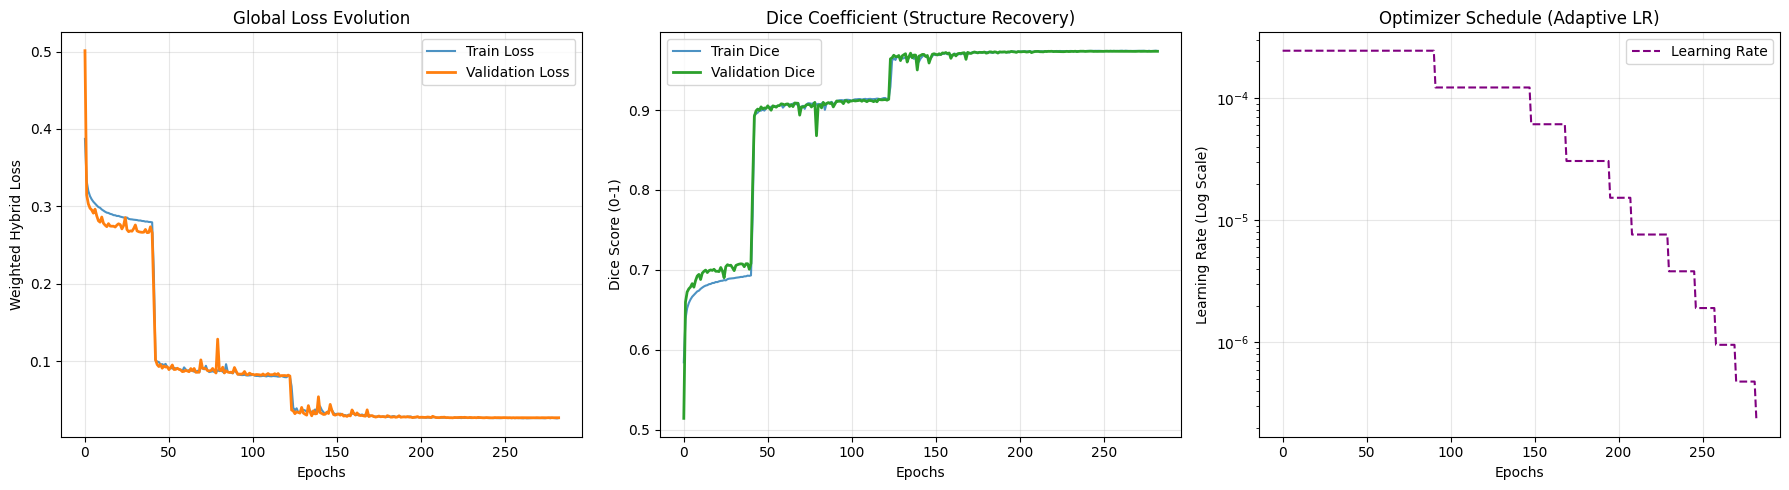

🧮 performing inference on Validation Set for detailed metrics...

🏆 Per-Class Segmentation Metrics:


,Class,IoU,Precision,Recall,Support (Pixels)
0,Background,0.993779,0.998011,0.995752,31848677
1,Stream,0.841569,0.895491,0.933227,707206
2,Cirrus,0.965830,0.977843,0.987440,4308117


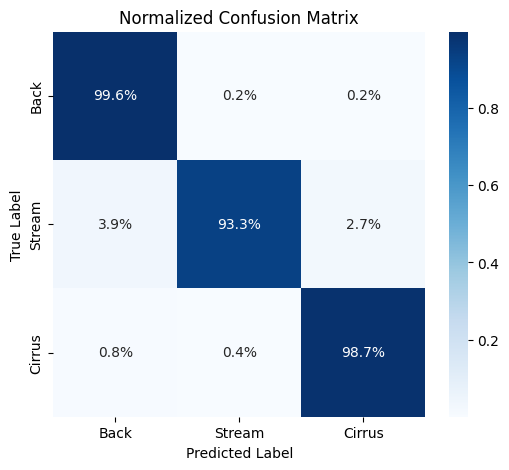

📷 Generating visual samples for qualitative analysis...
⚠️ Analyzing 'Hard Cases' (Lowest performance on Stream class)...
   - Worst Case #1: Index 1761, Stream Dice: 0.0000
   - Worst Case #2: Index 2000, Stream Dice: 0.0000
   - Worst Case #3: Index 543, Stream Dice: 0.0000
📦 Compressing results into TFM_FINAL_RESULTS.zip...
🏆 DONE! Download 'TFM_FINAL_RESULTS.zip' from the Output tab.


In [5]:
# ==========================================
# 📊 5. PERFORMANCE ANALYSIS & REPORTING
# ==========================================
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.metrics import confusion_matrix
from IPython.display import FileLink, display

# 1. Setup Output Directory
# We create a clean directory to store all artifacts (plots, CSVs, logs)
RESULTS_DIR = '/kaggle/working/tfm_results_final'
if os.path.exists(RESULTS_DIR):
    shutil.rmtree(RESULTS_DIR)
os.makedirs(RESULTS_DIR)

print(f"📄 Generating comprehensive performance report in: {RESULTS_DIR}")

# --- A. TRAINING HISTORY EXPORT ---
# Save raw numerical data for future plotting (e.g., in LaTeX/Overleaf)
hist_df = pd.DataFrame(history.history)
hist_path = os.path.join(RESULTS_DIR, 'history_training.csv')
hist_df.to_csv(hist_path, index_label='epoch')
print(f"✅ Training history saved to CSV.")

# --- B. LEARNING CURVES VISUALIZATION ---
plt.figure(figsize=(18, 5))

# 1. Loss Evolution
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', alpha=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Global Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Weighted Hybrid Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Dice Score Evolution (Shape Recovery)
plt.subplot(1, 3, 2)
plt.plot(history.history['dice_coef'], label='Train Dice', color='#1f77b4', alpha=0.8)
plt.plot(history.history['val_dice_coef'], label='Validation Dice', color='#2ca02c', linewidth=2)
plt.title('Dice Coefficient (Structure Recovery)')
plt.xlabel('Epochs')
plt.ylabel('Dice Score (0-1)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Learning Rate Decay
plt.subplot(1, 3, 3)
lr_key = 'lr' if 'lr' in history.history else 'learning_rate'
if lr_key in history.history:
    plt.plot(history.history[lr_key], label='Learning Rate', color='purple', linestyle='--')
    plt.yscale('log')
    plt.title('Optimizer Schedule (Adaptive LR)')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate (Log Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '01_training_dynamics.png'), dpi=300)
plt.show()

# --- C. QUANTITATIVE METRICS (CONFUSION MATRIX) ---
print("🧮 performing inference on Validation Set for detailed metrics...")

# Run Inference
preds = model.predict(X_val, batch_size=32, verbose=0)

# Flatten arrays for pixel-wise comparison
y_true_f = np.argmax(Y_val, axis=-1).flatten()
y_pred_f = np.argmax(preds, axis=-1).flatten()

# Compute Confusion Matrix
# Classes: 0=Background, 1=Stream, 2=Cirrus
cm = confusion_matrix(y_true_f, y_pred_f, labels=[0, 1, 2])

# Derived Metrics per Class
intersection = np.diag(cm)
union = cm.sum(axis=1) + cm.sum(axis=0) - intersection

# IoU, Precision, Recall Calculation
iou = intersection / (union + 1e-10)
precision = intersection / (cm.sum(axis=0) + 1e-10)
recall = intersection / (cm.sum(axis=1) + 1e-10)

# Create Metrics DataFrame
df_metrics = pd.DataFrame({
    'Class': ['Background', 'Stream', 'Cirrus'],
    'IoU': iou,
    'Precision': precision,
    'Recall': recall,
    'Support (Pixels)': cm.sum(axis=1)
})

# Export Metrics
df_metrics.to_csv(os.path.join(RESULTS_DIR, 'metrics_detailed_per_class.csv'), index=False)
print("\n🏆 Per-Class Segmentation Metrics:")
display(df_metrics)

# Normalize and Plot Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=['Back', 'Stream', 'Cirrus'], 
            yticklabels=['Back', 'Stream', 'Cirrus'])
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(RESULTS_DIR, '02_confusion_matrix.png'), dpi=300)
plt.show()

# Memory Cleanup
del y_true_f, y_pred_f, cm, cm_norm
gc.collect()

# --- D. QUALITATIVE ASSESSMENT (VISUAL INSPECTION) ---
print("📷 Generating visual samples for qualitative analysis...")

def save_visual_comparison(idx, filename):
    """Generates a side-by-side comparison: Input, GT, Prediction, Error Map."""
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    
    # 1. False Color Composite (Scientifically relevant mapping)
    # Assuming channels: 0=g, 1=r, 2=W1. Mapping W1->R, r->G, g->B to highlight structures.
    rgb = np.stack([X_val[idx,:,:,2], X_val[idx,:,:,1], X_val[idx,:,:,0]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6) # Min-Max Scaling
    
    ax[0].imshow(rgb)
    ax[0].set_title(f"Input Composite\n(Sample #{idx})")
    
    # 2. Ground Truth
    ax[1].imshow(np.argmax(Y_val[idx], axis=-1), vmin=0, vmax=2, cmap='viridis')
    ax[1].set_title("Ground Truth Mask")
    
    # 3. Prediction
    pred_mask = np.argmax(preds[idx], axis=-1)
    ax[2].imshow(pred_mask, vmin=0, vmax=2, cmap='viridis')
    ax[2].set_title("U-Net Prediction")
    
    # 4. Error Map (Binary: Correct vs Incorrect)
    gt_mask = np.argmax(Y_val[idx], axis=-1)
    error = (gt_mask != pred_mask)
    ax[3].imshow(error, cmap='Reds', vmin=0, vmax=1)
    ax[3].set_title("Pixel-wise Error Map")
    
    for a in ax: a.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150)
    plt.close()

# 1. Random Samples (General Performance)
import random
random_indices = random.sample(range(len(X_val)), 3)
for i, idx in enumerate(random_indices):
    save_visual_comparison(idx, f'visual_random_sample_{i}.png')

# 2. Hard Mining Analysis (Worst Cases for Streams)
# We specifically look for images where the Stream IoU is lowest
print("⚠️ Analyzing 'Hard Cases' (Lowest performance on Stream class)...")

# Extract stream channel (Class 1)
y_true_stream = Y_val[..., 1]
y_pred_stream = preds[..., 1]

# Compute Dice per image specifically for the Stream class
intersection = np.sum(y_true_stream * y_pred_stream, axis=(1, 2))
union = np.sum(y_true_stream, axis=(1, 2)) + np.sum(y_pred_stream, axis=(1, 2))
dice_scores = (2. * intersection) / (union + 1e-6)

# Filter: Only consider images that actually contain a stream (>10 pixels)
has_stream = np.sum(y_true_stream, axis=(1, 2)) > 10
candidate_indices = np.where(has_stream)[0]

if len(candidate_indices) > 0:
    # Sort by Dice Score (Ascending) -> Worst first
    worst_indices = candidate_indices[np.argsort(dice_scores[candidate_indices])][:3]
    
    for i, idx in enumerate(worst_indices):
        score = dice_scores[idx]
        print(f"   - Worst Case #{i+1}: Index {idx}, Stream Dice: {score:.4f}")
        save_visual_comparison(idx, f'visual_hard_case_{i}_dice_{score:.2f}.png')
else:
    print("   Note: No substantial streams found in validation set to analyze.")

# --- E. ARTIFACT PACKAGING ---
print("📦 Compressing results into TFM_FINAL_RESULTS.zip...")
shutil.make_archive('/kaggle/working/TFM_FINAL_RESULTS', 'zip', RESULTS_DIR)
print(f"🏆 DONE! Download 'TFM_FINAL_RESULTS.zip' from the Output tab.")